# <span style="color:teal"> Lezione 11 </span>
L'obiettivo di questa lezione è applicare il machine learning a un problema di regressione su dati rumorosi, utilizzando una Rete Neurale (NN). Vedremo in particolare come la capacità del modello di adattarsi ai dati dipenda dalla struttura della rete stessa.

### Il Problema della Previsione
Supponiamo che i dati $(x,y)$ siano generati da un processo probabilistico descritto dall'equazione:
$$y_i = f(x_i) + \eta_i$$
dove $f(x_i)$ è una funzione fissa (ma potenzialmente sconosciuta), mentre $\eta_i$ è un rumore gaussiano non correlato con valor medio nullo e varianza $\sigma$. La componente $f(x_i)$ rappresenta le caratteristiche vere del processo che ha generato i dati.  
Per fare previsioni, utilizziamo una rete neurale, i cui pesi e bias definiscono la cosiddetta classe di modelli, ovvero l'insieme di tutte le funzioni che la rete è in grado di rappresentare.

### Addestramento e Validazione
Il processo di apprendimento si divide in due fasi distinte:
- **Addestramento**: i parametri della rete vengono ottimizzati su un primo sottoinsieme di dati, detto set di training.
- **Validazione**: le prestazioni del modello vengono poi valutate su un secondo sottoinsieme, il set di test, che la rete non ha mai visto durante l'addestramento.

Questa separazione è fondamentale. L'obiettivo del machine learning non è memorizzare i dati di addestramento, ma generalizzare, ovvero fare previsioni accurate su dati nuovi e mai incontrati prima.

### Misura delle Prestazioni
Per quantificare la qualità delle previsioni, si confrontano i valori predetti $\{y_j^\mathrm{pred}\}$ con quelli reali $\{y_j\}$ sul dataset di test, calcolando l'Errore Quadratico Medio (MSE):
$$ MSE = \frac{1}{N_\mathrm{test}} \sum_{j=1}^{N_\mathrm{test}} \left(y_j^\mathrm{pred} - y_j\right)^2$$
Oltre a questa misura numerica, analizzeremo visivamente i risultati tramite grafici sia sul set di addestramento che su quello di validazione, per ottenere un quadro qualitativo delle prestazioni del modello.

## <span style="color:turquoise"> Esercizio 11.1 </span>

In questo esercizio è stato chiesto di applicare quanto descritto sopra alla funzione più semplice possibile: 
$$f(x) = 2x + 1$$
considerando solamente l'intervallo $x \in [-1,1]$.


Per fare pratica con le reti neurali, esploriamo come la qualità della regressione lineare dipenda da tre iperparametri fondamentali:
- $N_\mathrm{train}$: il numero di punti di training. Troppi pochi campioni rendono la stima del gradiente rumorosa e i pesi appresi oscillano lontano dai valori reali.

- $N_\mathrm{epochs}$: il numero di volte che la rete vede l'intero set di training. Se troppo piccolo, il training si interrompe mentre la loss è ancora in discesa e i pesi non hanno raggiunto il minimo.

- $\sigma$: la deviazione standard del rumore di misura. Più questo valore è grande, più i dati sono dispersi attorno alla retta vera, rendendo difficile per la rete distinguere il segnale dal rumore. Vale inoltre un limite teorico fondamentale: la MSE non può mai scendere sotto $\sigma^2$, indipendentemente da quanti dati si usino o per quante epoche si alleni la rete. È però importante includere $\sigma > 0$ per rappresentare la realtà: i dati sperimentali sono sempre affetti da rumore di misura, e testare la rete in queste condizioni è essenziale per valutarne la robustezza reale.

I tre parametri non sono indipendenti tra loro: un elevato livello di rumore può essere parzialmente compensato da una maggiore quantità di dati, mentre un numero insufficiente di epoche risulta tanto più critico quanto più lenta è la convergenza del training. La scelta della configurazione ottimale di questi parametri è quindi un aspetto fondamentale per garantire le prestazioni della rete neurale.

### Generazione dei dati e visualizzazione grafica
Prima di costruire la rete neurale, generiamo i dati su cui essa verrà addestrata e valutata. I dati vengono prodotti campionando $N_\mathrm{train} = 1000$ punti $x_i \sim \mathcal{U}(-1, 1)$ e aggiungendo rumore gaussiano $\sigma = 0.1$.

Il dataset viene suddiviso in due insiemi distinti: il set di training ($N_\mathrm{train} = 1000$), utilizzato per ottimizzare i parametri della rete, e il set di test ($100$ punti), tenuto separato e usato esclusivamente per valutare le prestazioni del modello su dati mai visti durante il training. Il set di validazione viene inoltre ordinato lungo $x$ per facilitare la visualizzazione grafica. 

Il grafico mostra la sovrapposizione tra la retta target ideale e i dati di validazione rumorosi, offrendo un riferimento visivo immediato di quanto il rumore perturbi il segnale vero.

In [1]:
# generazione dei dati
import numpy as np

# parametri target di f(x) = m*x + b
m = 2
b = 1 

# genera input di training
N_train = 1000

np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 100)
x_valid.sort()
y_target = m * x_valid + b 

sigma = 0.1 # rumore devstd

y_train = np.random.normal(m * x_train + b, sigma) # misure da cui vogliamo ottenere i parametri della retta
y_valid = np.random.normal(m * x_valid + b, sigma)

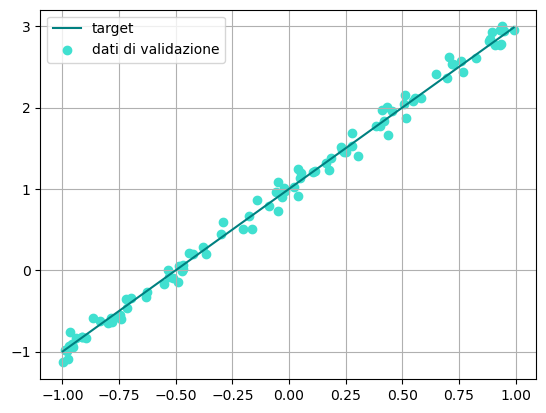

In [2]:
# plot dati di validazione e di target
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target', color='teal')
plt.scatter(x_valid, y_valid, color='turquoise', label='dati di validazione')
plt.legend()
plt.grid(True)
plt.show()

### Costruzione e compilazione del modello
La rete neurale è implementata tramite i metodi di Keras e presenta un'architettura minimale: un singolo layer `Dense` composto da un solo neurone privo di funzione di attivazione, che riceve in ingresso un unico valore scalare $x$. Tale configurazione è del tutto equivalente a un modello lineare della forma $y= wx + b$ dove $w$ e $b$
rappresentano rispettivamente il peso e il bias che la rete dovrà stimare a partire dai dati di training.

Una volta definita l'architettura, il modello viene compilato specificando due elementi fondamentali:

- **Ottimizzatore SGD (Stochastic Gradient Descent)**: aggiorna i pesi della rete nella direzione opposta al gradiente della loss, calcolato su un sottoinsieme casuale (minibatch) dei dati di training ad ogni passo. Rispetto al gradiente calcolato sull'intero dataset, questo approccio è computazionalmente più efficiente e introduce una variabilità che può aiutare a sfuggire a minimi locali.

- **Loss MSE (Mean Squared Error)**: misura la discrepanza tra i valori predetti dalla rete e quelli reali, calcolando la media dei quadrati degli errori. È la scelta naturale per problemi di regressione, poiché penalizza maggiormente gli errori grandi e il suo gradiente è analitico e ben definito ovunque.

La stessa metrica MSE viene anche monitorata durante il training per tracciare l'andamento delle prestazioni su entrambi i set.

In [3]:
# composizione del modello NN
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(0)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(1))

# compilazione del modello scegliendo l'ottimizzatore, la loss e gli oggetti metrici
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

### Addestramento del modello
Il modello viene addestrato tramite il metodo `model.fit()`, che esegue l'ottimizzazione dei parametri $w$ e $b$ sui dati di training. I parametri rilevanti sono:

- `batch_size=32`: ad ogni passo di ottimizzazione il gradiente viene calcolato su un sottoinsieme di 32 campioni estratti casualmente dal set di training, anziché sull'intero dataset. Questo rende ogni aggiornamento più rapido e introduce una variabilità che favorisce la convergenza.

- `epochs=30`: la rete vede l'intero training set per 30 volte consecutive, aggiornando i pesi ad ogni minibatch.

  
- `shuffle=True`: i dati vengono rimescolati prima di ogni epoca, in modo che la sequenza dei minibatch sia diversa ad ogni passaggio. Questo evita che la rete apprenda pattern legati all'ordine dei dati anziché alla struttura del problema.

  
- `validation_data`: ad ogni epoca, oltre alla loss sul set di training, viene calcolata automaticamente la MSE sul set di validazione. Questo permette di monitorare in tempo reale se il modello sta generalizzando correttamente o se sta iniziando a sovradattarsi ai dati di training.

L'intero storico delle metriche viene salvato nell'oggetto `history`, che sarà utilizzato successivamente per visualizzare l'andamento della loss durante il training.

In [4]:
# fit del modello usando i dati di training
N_epoches = 30

history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=N_epoches,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.9217 - mse: 3.9217 - val_loss: 3.2709 - val_mse: 3.2709
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.3428 - mse: 2.3428 - val_loss: 2.0532 - val_mse: 2.0532
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4654 - mse: 1.4654 - val_loss: 1.3203 - val_mse: 1.3203
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9369 - mse: 0.9369 - val_loss: 0.8585 - val_mse: 0.8585
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6057 - mse: 0.6057 - val_loss: 0.5618 - val_mse: 0.5618
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3942 - mse: 0.3942 - val_loss: 0.3695 - val_mse: 0.3695
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2581 - mse: 0.2581 - val_loss: 0.2445 - val_mse: 0.2445
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1703 - mse: 0.1703 - val_loss: 0.1631 - val_mse: 0.1631
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1135 - mse:

### Valutazione del modello
Una volta completato il training, il modello viene valutato quantitativamente tramite `model.evaluate()`, che calcola la MSE su un dato insieme di coppie $(x, y)$. La valutazione viene eseguita in due modi distinti:

- **Confronto con i dati rumorosi** (`y_valid`): la MSE viene calcolata rispetto ai valori di validazione affetti da rumore. Questo rappresenta la prestazione realistica del modello, quella che si otterrebbe in un contesto sperimentale reale.
  
- **Confronto con la curva target esatta** (`y_target`): la MSE viene calcolata rispetto ai valori ideali $f(x) = 2x + 1$, privi di rumore. Questo fornisce una misura di quanto i parametri appresi $w$ e $b$ si discostino dai valori veri $m=2$ e $b=1$, indipendentemente dal rumore. Una MSE vicina a zero indica che la rete ha recuperato correttamente la funzione sottostante.

In [5]:
# valutazione del modello
print("Valutazione del modello con i dati rumorosi:")
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# stampa loss e accuracy

print('Test loss:', score[0])
print('Test accuracy:', score[1])

print()
# valutazione del modello con la curva esatta
print("Valutazione del modello con la curva esatta: ")
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# stampa loss e accuracy

print('Test loss:', score[0])
print('Test accuracy:', score[1])
print()

Valutazione del modello con i dati rumorosi:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0083 - mse: 0.0083
Test loss: 0.008273926563560963
Test accuracy: 0.008273926563560963

Valutazione del modello con la curva esatta: 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.2219e-05 - mse: 1.2219e-05
Test loss: 1.221940965479007e-05
Test accuracy: 1.221940965479007e-05



La MSE calcolata sui dati rumorosi è $\approx 0.0083$, un valore piccolo ma non nullo, attribuibile esclusivamente alla dispersione del rumore nei dati di validazione.   
La MSE calcolata rispetto alla curva di target esatta è invece $\approx 1.2 \times 10^{-5}$, praticamente nulla. Questo significa che i parametri appresi dalla rete $w$ e $b$ coincidono con estrema precisione con i valori veri $m=2$ e $b=1$ . 

La differenza tra i due valori dimostra che il modello ha correttamente separato il segnale dal rumore, adattandosi alla struttura lineare sottostante senza sovradattarsi alle fluttuazioni casuali dei dati.

### Visualizzazione dell'andamento della Loss durante il training
Per analizzare il comportamento della rete durante l'addestramento, viene visualizzato l'andamento della MSE epoca per epoca, sia sul training set che sul validation set. Una loss decrescente e che tende a stabilizzarsi conferma che la rete sta convergendo correttamente. Invece se la loss di training dovesse scendere mentre quella di validazione rimane alta o risale, si è in presenza di overfitting, ovvero la rete sta memorizzando i dati di training anziché generalizzare.   
In questo caso, data la semplicità del modello lineare, ci si aspetta che le due curve decrescano in modo analogo e convergano verso valori simili.

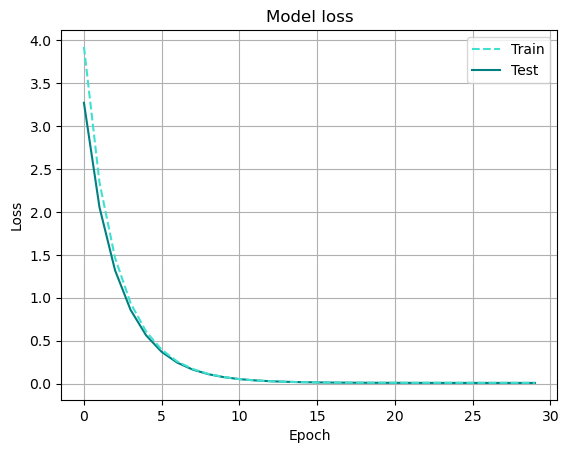

In [6]:
# Plot della loss di training e di validazione
plt.plot(history.history['loss'], color ='turquoise', ls='--', zorder=5)
plt.plot(history.history['val_loss'], color = 'teal')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid()
plt.show()

Nel grafico è raffigurato l'andamento della Loss di training e di test. Le due curve decrescono rapidamente e in modo sostanzialmente sovrapposto: alla prima epoca la loss parte da valori intorno a $\approx 1.75$ per il training e $\approx 1.25$ per il test e converge verso zero già attorno all'epoca $15$, per poi stabilizzarsi completamente nelle epoche successive. 

Il fatto che la curva di training e quella di validazione siano praticamente indistinguibili per tutto il training esclude qualsiasi fenomeno di overfitting: il modello generalizza sul validation set esattamente come si comporta sui dati di training. Il plateau raggiunto intorno all'epoca $15$ indica che ulteriori epoche di training non apporterebbero alcun miglioramento significativo.

### Predizione su nuovi dati
Come verifica finale, il modello addestrato viene utilizzato per fare predizioni su un insieme di $50$ punti nuovi, generati casualmente in $[−1,1]$ e mai visti durante il training. I valori predetti $y(x) = wx + b$ vengono poi confrontati graficamente con la retta target esatta $f(x) = 2x + 1$. Se i punti predetti giacciono sulla retta target, significa che la rete ha correttamente appreso i parametri della funzione lineare sottostante. Questo passaggio rappresenta il vero test del modello, ovvere se è in grado di generalizzare correttamente input arbitrari all'interno del dominio.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


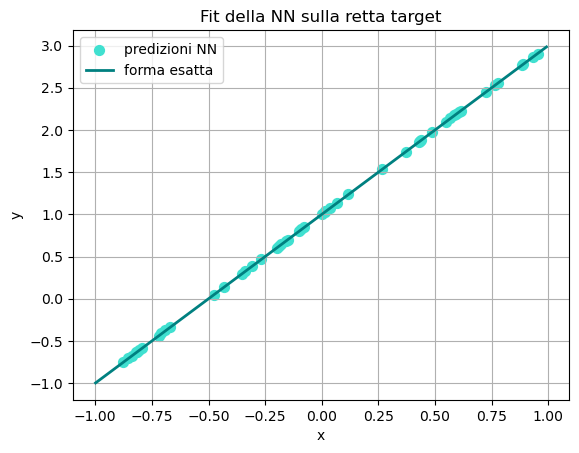

In [8]:
# predizione su dati nuobi
x_predicted = np.random.uniform(-1, 1, 50)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='turquoise', s=50, zorder=1, label='predizioni NN')
plt.plot(x_valid, y_target, color = 'teal', lw=2, zorder=2, label = 'forma esatta')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fit della NN sulla retta target')
plt.grid(True)
plt.legend()
plt.show()

I punti predetti dalla rete si sovrappongono con estrema precisione alla retta target $f(x) = 2x + 1$ su tutto il dominio $[-1, 1]$, senza alcuna deviazione apprezzabile. Questo conferma quanto già indicato dalla MSE sul target: la rete ha recuperato correttamente i parametri della funzione lineare sottostante e generalizza in modo accurato su input nuovi. Il risultato è la dimostrazione visiva che l'addestramento è andato a buon fine.

### Conclusioni
I risultati ottenuti confermano che la rete neurale, pur nella sua architettura minimale, è in grado di recuperare con grande precisione i parametri della funzione lineare $f(x) = 2x + 1$, raggiungendo una MSE sul target di $\approx 1.2 \times 10^{-5}$ e una convergenza completa già intorno all'epoca $15$.

La qualità del risultato dipende tuttavia in modo critico dalla scelta dei parametri di training. Dalle analisi condotte emerge che:

- $N_\mathrm{train}$: con meno di $700$ punti di training il gradiente risulta troppo rumoroso e i pesi appresi $w$ e $b$  si discostano sensibilmente dai valori target.

- $N_\mathrm{epochs}$: con meno di $20$ epoche il training si interrompe mentre la loss è ancora in discesa e i pesi non hanno raggiunto il minimo. Nel grafico della loss si osserva che la convergenza avviene intorno all'epoca $15$, confermando che $30$ epoche rappresentano una scelta adeguata per questo problema.

  
- $\sigma$: con valori di rumore superiori a $0.5$ il rapporto segnale-rumore degrada significativamente e la regressione diventa inaffidabile.

In definitiva, la configurazione $N_\mathrm{train} = 1000$, $N_\mathrm{epochs} = 30$ e $\sigma = 0.1$ si è rivelata ottimale per questo problema, garantendo convergenza rapida, assenza di overfitting e un'eccellente approssimazione della funzione target.

## <span style="color:turquoise"> Esercizio 11.2 </span>
In questo esercizio è stato chiesto di estendere il caso lineare dell'esercizio precedente, considerando una funzione più complessa (un polinomio di terzo grado):
$$f(x) = 4 - 3x - 2x^2 + 3x^3, \qquad x \in [-1, 1]$$ 
A differenza del caso lineare, approssimare un polinomio di terzo grado richiede una rete più espressiva, con layer multipli, più neuroni e funzioni di attivazione non lineari. L'obiettivo è trovare una configurazione architetturale adeguata e valutarne le prestazioni sia all'interno del dominio di training che al di fuori di esso.

### Generazione dei dati e visualizzazione grafica
La struttura della generazione dei dati è analoga all'esercizio precedente, con la differenza che la funzione target è ora il polinomio di terzo grado $f(x) = 3x^3 - 2x^2 - 3x + 4$. Vengono generati $N_\mathrm{train} = 5000$  punti di training e $1000$ punti di validazione, campionati uniformemente in $[−1,1]$ e perturbati da rumore gaussiano con $\sigma = 0.1$.

Rispetto all'esercizio precedente, il numero di punti di training è stato aumentato a $5000$: la maggiore complessità della funzione target richiede infatti più dati per consentire alla rete di apprendere correttamente le variazioni non lineari del polinomio su tutto il dominio.

Il grafico mostra la sovrapposizione tra la funzione target ideale e i dati di validazione rumorosi, offrendo un riferimento visivo immediato di quanto il rumore perturbi il segnale vero.

In [30]:
# generazione dei dati
import numpy as np

# parametri target di f(x) = ax^3+bx^2+cx+d
a = 3
b = -2
c = -3
d = 4

# generate training inputs
N_train = 5000

np.random.seed(0)
x_train = np.random.uniform(-1, 1, N_train)
x_valid = np.random.uniform(-1, 1, 1000)
x_valid.sort()
y_target = a * x_valid**3 + b * x_valid**2 + c * x_valid + d

sigma = 0.1 # noise standard deviation, for the moment it is absent

y_train = np.random.normal(a * x_train**3 + b * x_train**2 + c * x_train + d, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(a * x_valid**3 + b * x_valid**2 + c * x_valid + d, sigma)

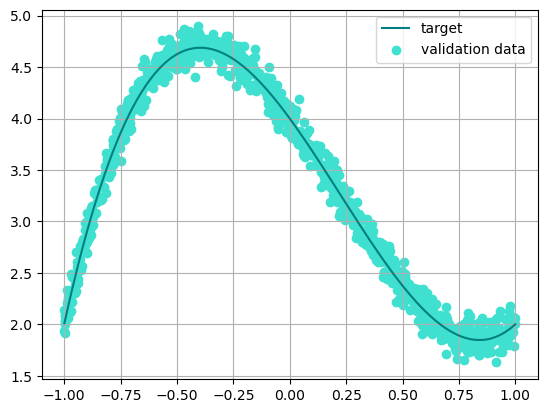

In [31]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target', color='teal')
plt.scatter(x_valid, y_valid, color='turquoise', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

### Costruzione e compilazione del modello
A differenza dell'esercizio precedente, la rete necessita di una struttura più profonda per catturare la non linearità del polinomio. L'architettura è composta da:

- Tre layer `Dense` nascosti con rispettivamente 64, 32 e 16 neuroni, il cui numero decresce progressivamente verso l'output per estrarre rappresentazioni via via più compatte del segnale. Ogni neurone di un layer `Dense` è connesso a tutti i neuroni del layer precedente, garantendo la massima capacità espressiva ad ogni livello.

- Funzione di attivazione `ReLU` (Rectified Linear Unit), definita come ReLU(x) = max(0, x), applicata a ciascun layer nascosto. Introduce la non linearità necessaria per approssimare funzioni complesse: senza di essa, la composizione di layer lineari rimarrebbe una funzione lineare indipendentemente dalla profondità della rete.
- Layer di output composto da un singolo neurone lineare `Dense`, coerentemente con il fatto che il problema richiede una predizione su scala continua.
- Ottimizzatore SGD e loss MSE, per le stesse ragioni discusse nell'esercizio precedente.

In [32]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(2)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

### Addestramento del modello
La fase di addestramento è strutturata in modo identico all'esercizio precedente: $30$ epoche, minibatch di $32$ campioni e rimescolamento dei dati ad ogni epoca. L'unica differenza rilevante è che in questo caso il training set è composto da $5000$ punti anziché 1000, scelta motivata dalla maggiore complessità della funzione target che richiede più esempi affinché la rete apprenda correttamente le variazioni non lineari del polinomio. Come in precedenza, l'oggetto `history` registra l'andamento della loss su training e validation set epoca per epoca, e verrà utilizzato per verificare la convergenza del modello.

In [33]:
# addestramento del modello
N_epoches = 30

history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=N_epoches,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2671 - mse: 1.2671 - val_loss: 0.3174 - val_mse: 0.3174
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1972 - mse: 0.1972 - val_loss: 0.1394 - val_mse: 0.1394
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0843 - mse: 0.0843 - val_loss: 0.0675 - val_mse: 0.0675
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0447 - mse: 0.0447 - val_loss: 0.0414 - val_mse: 0.0414
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0293 - mse: 0.0293 - val_loss: 0.0300 - val_mse: 0.0300
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0220 - mse: 0.0220 - val_loss: 0.0237 - val_mse: 0.0237
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0181 - mse: 0.0181 - val_loss: 0.0199 - val_mse: 0.0199
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0174 - val_mse: 0.0174
Epoch 9/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

### Valutazione del modello
La valutazione segue lo stesso schema dell'esercizio precedente: il modello viene testato due volte tramite `model.evaluate()`, prima sui dati di validazione rumorosi e poi sulla curva target esatta. Il confronto tra i due valori di MSE permette di distinguere l'errore dovuto al rumore da quello dovuto all'approssimazione della rete: una MSE bassa sul target indica che la rete ha appreso correttamente la forma del polinomio, mentre la MSE sui dati rumorosi include inevitabilmente il contributo del rumore di misura e rappresenta quindi un limite superiore alle prestazioni realistiche del modello.

In [34]:
# evaluate model
print("Valutazione del modello con i dati rumorosi:")
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance

print('Test loss:', score[0])
print('Test accuracy:', score[1])

print()

# evaluate model with the exact curve
print("Valutazione del modello con la curva esatta: ")
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance

print('Test loss:', score[0])
print('Test accuracy:', score[1])

print()

Valutazione del modello con i dati rumorosi:
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0109 - mse: 0.0109
Test loss: 0.010860435664653778
Test accuracy: 0.010860435664653778

Valutazione del modello con la curva esatta: 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2890e-04 - mse: 9.2890e-04
Test loss: 0.0009288964211009443
Test accuracy: 0.0009288964211009443



La MSE sui dati rumorosi è ≈$\approx 0.0109$, mentre quella sulla curva esatta scende a $\approx 0.0009$: la rete ha quindi appreso una buona approssimazione del polinomio. I valori sono leggermente più alti rispetto al caso lineare, il che era prevedibile data la maggiore complessità della funzione target. La differenza tra le due MSE conferma l'assenza di overfitting.

### Visualizzazione dell'andamento della Loss durante il training
Viene visualizzato l'andamento della MSE epoca per epoca sui set di training e di validazione, con le stesse finalità diagnostiche dell'esercizio precedente: verificare che la loss converga e che le due curve rimangano sovrapposte, escludendo fenomeni di overfitting. In questo caso ci si aspetta una convergenza più lenta rispetto al caso lineare, data la maggiore complessità della funzione target e la profondità della rete.

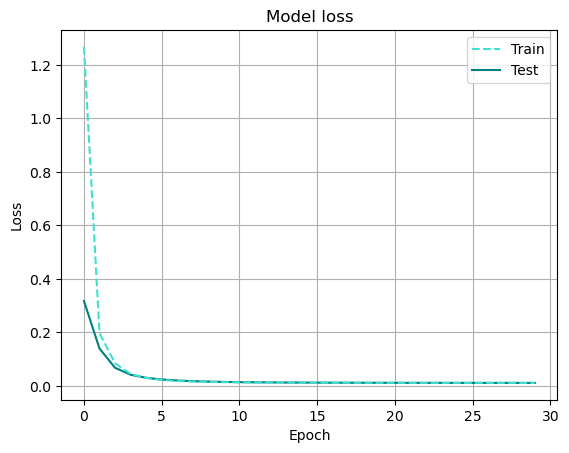

In [35]:
# Plot training & validation loss values
plt.plot(history.history['loss'], color ='turquoise', ls='--', zorder=5)
plt.plot(history.history['val_loss'], color = 'teal')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid()
plt.show()

Nel grafico è raffigurato l'andamento della Loss di training e di test. Entrambe le curve decrescono rapidamente nelle prime 5 epoche, con la loss di training che parte da $\approx 1.2$ e quella di validazione da $\approx 0.3$, per poi convergere e sovrapporsi quasi perfettamente già intorno all'epoca $10$ e stabilizzarsi su valori prossimi a zero. L'assenza di overfitting è confermata dalla sovrapposizione delle due curve. Rispetto al caso lineare la convergenza è più rapida e netta, a testimonianza che l'architettura scelta è ben adatta alla complessità della funzione target.

### Predizione su nuovi dati e analisi dei residui
Per valutare le prestazioni del modello in modo più approfondito, le predizioni vengono estese a un intervallo più ampio rispetto a quello di training, specificamente $x \in [-1.2, 1.5]$, e confrontate con la curva teorica tramite due grafici affiancati.

Il primo grafico sovrappone le predizioni della rete alla curva teorica, con le linee verticali tratteggiate che delimitano il dominio di training $[−1,1]$. Questo permette di valutare visivamente non solo la qualità del fit all'interno del dominio, ma anche la capacità di estrapolazione al di fuori di esso.

Il secondo grafico mostra i residui $f(x) - y(x)$, ovvero la differenza puntuale tra la curva teorica e le predizioni della rete. Residui prossimi a zero indicano un fit accurato, mentre eventuali deviazioni sistematiche, specialmente al di fuori del dominio di training, rivelano i limiti di generalizzazione del modello.

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


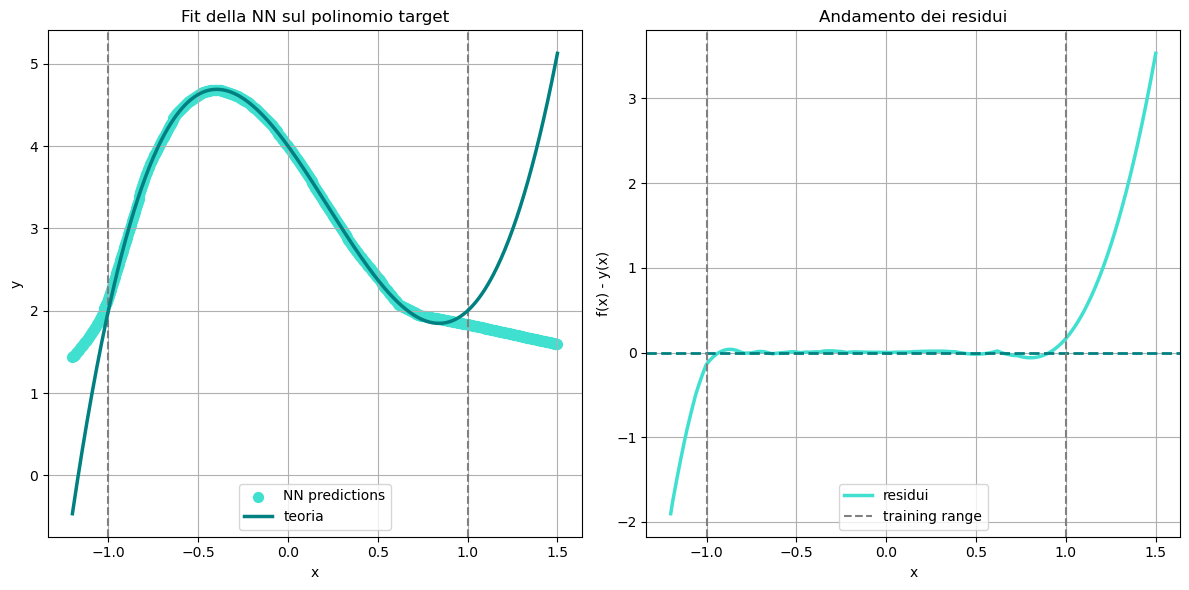

In [36]:
#grafici e plot
import numpy as np

x_predicted = np.linspace(-1.2, 1.5, 500)
y_predicted = model.predict(x_predicted)

sort_idx = np.argsort(x_predicted)
x_sorted = x_predicted[sort_idx]
y_pred_sorted = y_predicted[sort_idx].flatten()

x_theory = np.linspace(-1.2, 1.5, 500)
y_theory = a * x_theory**3 + b * x_theory**2 + c * x_theory + d

residuals = y_theory - y_pred_sorted

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# --- Grafico 1: predizioni vs teoria ---
ax1.scatter(x_sorted, y_pred_sorted, color='turquoise', s=50, zorder=1, label='NN predictions')
ax1.plot(x_theory, y_theory, color='teal', lw=2.5, zorder=3, label='teoria')
ax1.axvline(x=1, color='grey', ls='--')
ax1.axvline(x=-1, color='grey', ls='--')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Fit della NN sul polinomio target')
ax1.legend()
ax1.grid(True)

# --- Grafico 2: residui ---
ax2.plot(x_sorted, residuals, color='turquoise', lw=2.5, label = 'residui')
ax2.axhline(y=0, color='teal', lw=2, linestyle='--')
ax2.axvline(x=1, color='grey', ls='--', label='training range')
ax2.axvline(x=-1, color='grey', ls='--')
ax2.set_xlabel('x')
ax2.set_ylabel('f(x) - y(x)')
ax2.set_title('Andamento dei residui')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

All'interno del dominio di training $[−1,1]$ le predizioni della rete si sovrappongono con grande precisione alla curva teorica, e i residui rimangono praticamente nulli su tutto l'intervallo, a parte qualche difficoltà agli estremi, confermando la qualità del fit. Al di fuori del dominio il comportamento degrada rapidamente in entrambe le direzioni. Questo comportamento è una conseguenza diretta del fatto che la rete non apprende la forma analitica della funzione, ma ne costruisce un'approssimazione locale valida esclusivamente nel dominio su cui è stata addestrata. Al di fuori di esso, in assenza di dati, la rete estrapola in modo arbitrario e inaffidabile.

### Conclusioni
I risultati confermano che l'architettura scelta, tre layer Dense con attivazione ReLU, è adeguata per approssimare il polinomio di terzo grado all'interno del dominio di training, raggiungendo una MSE sul target di $\approx 0.0009$. All'esterno del dominio le predizioni divergono rapidamente, evidenziando il limite fondamentale delle reti neurali: esse non apprendono la struttura analitica della funzione, ma ne costruiscono un'approssimazione locale valida esclusivamente nell'intervallo su cui sono state addestrate.

## <span style="color:turquoise"> Esercizio 11.3 </span>
In questo esercizio è stato chiesto di estendere il problema a una funzione di due variabili:
$$f(x, y) = \sin(x^2 + y^2), \qquad x, y \in \left[-\frac{3}{2}, \frac{3}{2}\right]$$
Rispetto ai casi precedenti, l'input è bidimensionale e la funzione presenta una struttura oscillante con simmetria radiale, il che rende il problema significativamente più complesso e richiede un'architettura adeguata.

### Generazione dei Dati e visualizzazione grafica
La generazione dei dati segue lo stesso schema degli esercizi precedenti, con le opportune modifiche per il caso bidimensionale. Vengono generati $N_\mathrm{train} = 10000$ punti di training e $2000$ di validazione, campionando indipendentemente $x$ e $y$ da una distribuzione uniforme in $[−3/2,3/2]$. Il rumore gaussiano è stato diminuito a $\sigma = 0.05$.

Il numero di punti è significativamente più alto rispetto agli esercizi precedenti: coprire un dominio bidimensionale in modo sufficientemente denso richiede molti più campioni rispetto al caso 1D. 

Per la visualizzazione viene costruita una griglia regolare 100×100 tramite `meshgrid`, su cui viene calcolata la superficie target esatta e sovrapposta ai punti di validazione rumorosi.

In [37]:
# generazione dei dati
import numpy as np

# generate training inputs
N_train = 10000

np.random.seed(0)
x_train = np.random.uniform(-1.5, 1.5, N_train)
x_valid = np.random.uniform(-1.5, 1.5, 2000)
#x_valid.sort()
y_train = np.random.uniform(-1.5, 1.5, N_train)
y_valid = np.random.uniform(-1.5, 1.5, 2000)
#y_valid.sort()

y_target = np.sin(x_valid**2 + y_valid**2)

sigma = 0.05 # noise standard deviation, for the moment it is absent

z_train = np.random.normal(np.sin(x_train**2 + y_train**2), sigma) # actual measures from which we want to guess regression parameters
z_valid = np.random.normal(np.sin(x_valid**2 + y_valid**2), sigma)

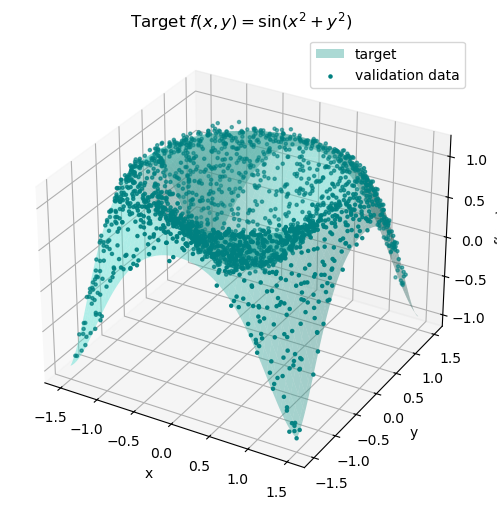

In [38]:
# plot dei dati
import matplotlib.pyplot as plt

x_grid = np.linspace(-1.5, 1.5, 100)
y_grid = np.linspace(-1.5, 1.5, 100)
x_grid, y_grid = np.meshgrid(x_grid, y_grid)
z_grid = np.sin(x_grid**2 + y_grid**2)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x_grid, y_grid, z_grid, alpha=0.4, color='turquoise', label='target')
ax.scatter(x_valid, y_valid, z_valid, color='teal', label='validation data', s=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.set_title('Target $f(x,y) = \sin(x^2 + y^2)$')
ax.legend()
ax.grid(True)
plt.show()

### Costruzione e compilazione del modello
Rispetto all'esercizio precedente, l'architettura viene ampliata per far fronte alla maggiore complessità della funzione target. Il layer di input accetta ora vettori di dimensione 2, poiché ogni campione è una coppia $(x,y)$. I layer nascosti `Dense` sono quattro, con rispettivamente 128, 64, 32 e 16 neuroni e attivazione `ReLU`, seguiti da un singolo neurone lineare in output.

In [44]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(2)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

### Addestramento del Modello
La fase di addestramento introduce una novità rispetto agli esercizi precedenti: poiché l'input è bidimensionale, le coordinate $x$ e $y$ vengono combinate in un'unica matrice tramite `np.column_stack`, producendo array di forma $(N_\mathrm{train}, 2)$ e $(N_\mathrm{valid}, 2)$ che la rete riceve come input. 

Il resto della procedura rimane invariato: $50$ epoche, minibatch di $32$ campioni e rimescolamento ad ogni epoca. Il numero di epoche è stato aumentato a 50 rispetto ai 30 degli esercizi precedenti, per dare alla rete più tempo per convergere su una funzione target più complessa.

In [45]:
N_epoches = 50

XY_train = np.column_stack([x_train, y_train])  # shape (10000, 2)
XY_valid = np.column_stack([x_valid, y_valid])  # shape (2000, 2)

history = model.fit(x=XY_train, y=z_train,
          batch_size=32, epochs=N_epoches,
          shuffle=True,
          validation_data=(XY_valid, z_valid))

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1631 - mse: 0.1631 - val_loss: 0.1341 - val_mse: 0.1341
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1398 - mse: 0.1398 - val_loss: 0.1218 - val_mse: 0.1218
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1263 - mse: 0.1263 - val_loss: 0.1091 - val_mse: 0.1091
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1106 - mse: 0.1106 - val_loss: 0.0932 - val_mse: 0.0932
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0912 - mse: 0.0912 - val_loss: 0.0736 - val_mse: 0.0736
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0686 - mse: 0.0686 - val_loss: 0.0529 - val_mse: 0.0529
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0467 - mse: 0.0467 - val_loss: 0.0344 - val_mse: 0.0344
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0295 - mse: 0.0295 - val_loss: 0.0215 - val_mse: 0.0215
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

### Valutazione del modello
La valutazione segue lo stesso schema degli esercizi precedenti: il modello viene testato tramite `model.evaluate()` prima sui dati rumorosi z_valid e poi sulla curva target esatta y_target. L'unica differenza è che l'input passato al modello è ora la matrice XY_valid di forma $(2000, 2)$, contenente le coppie $(x, y)$ del validation set, anziché un semplice array monodimensionale.

In [46]:
# evaluate model
print("Valutazione del modello con i dati rumorosi:")
score = model.evaluate(XY_valid, z_valid, batch_size=32, verbose=1)

# print performance
print('Test loss:', score[0])
print('Test accuracy:', score[1])

print()

# evaluate model with the exact curve
score = model.evaluate(XY_valid, y_target, batch_size=32, verbose=1)

# print performance
print("Valutazione del modello con la curva esatta: ")
print('Test loss:', score[0])
print('Test accuracy:', score[1])

print()

Valutazione del modello con i dati rumorosi:
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0029 - mse: 0.0029
Test loss: 0.0028651554603129625
Test accuracy: 0.0028651554603129625

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5654e-04 - mse: 2.5654e-04
Valutazione del modello con la curva esatta: 
Test loss: 0.00025653804186731577
Test accuracy: 0.00025653804186731577



La MSE sui dati rumorosi è $\approx 0.0029$, mentre quella sulla curva esatta è $\approx 2.6 \times 10^{-4}$: già con questa prima configurazione i risultati sono molto soddisfacenti. La rete ha appreso la struttura oscillante della funzione con grande precisione, e la differenza tra i due valori di MSE è interamente spiegata dal rumore di misura.

### Visualizzazione dell'andamento della Loss durante il training
Viene visualizzato l'andamento della MSE epoca per epoca su training e validation set, con le stesse finalità diagnostiche degli esercizi precedenti. In questo caso ci si aspetta una convergenza più lenta rispetto al caso polinomiale, data la maggiore complessità della funzione target e la natura bidimensionale del problema.

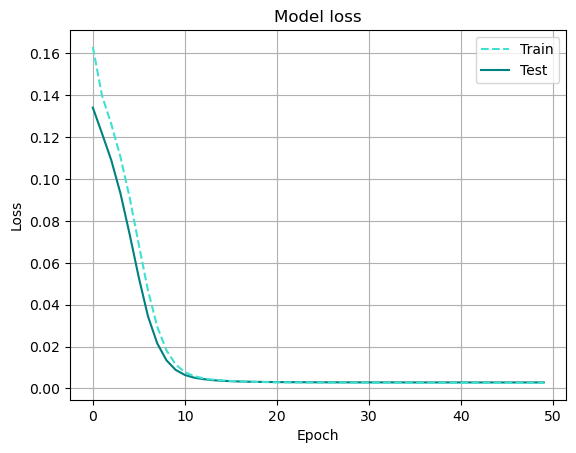

In [47]:
# Plot training & validation loss values
plt.plot(history.history['loss'], color ='turquoise', ls='--', zorder=5)
plt.plot(history.history['val_loss'], color = 'teal')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid()
plt.show()

Nel grafico è raffigurato l'andamento della Loss di training e di test. Entrambe le curve decrescono rapidamente e in modo sovrapposto con la loss di training che parte da $\approx 0.16$ e quella di validazione da $\approx 0.13$, stabilizzandosi già attorno all'epoca $20$ su valori prossimi a zero. L'assenza di separazione tra la curva di training e quella di validazione conferma che non vi è overfitting. La convergenza è rapida e netta, a testimonianza che l'architettura scelta è adeguata.

### Predizione su nuovi dati e analisi dei residui
Per valutare le prestazioni del modello vengono generati $1000$ punti casuali nel dominio $x,y  \in [-3/2, 3/2]$, le cui coordinate vengono combinate in una matrice tramite `np.column_stack` e passate alla rete per ottenere le predizioni. Parallelamente, il modello viene valutato sull'intera griglia 100×100 per calcolare la mappa dei residui $f(x,y)−y(x,y)$.

I risultati vengono visualizzati tramite due grafici affiancati: il primo sovrappone i punti predetti alla superficie target in 3D, offrendo un confronto visivo immediato; il secondo mostra la mappa dei residui come heatmap 2D, che permette di identificare con precisione le zone del dominio dove l'approssimazione della rete è meno accurata.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


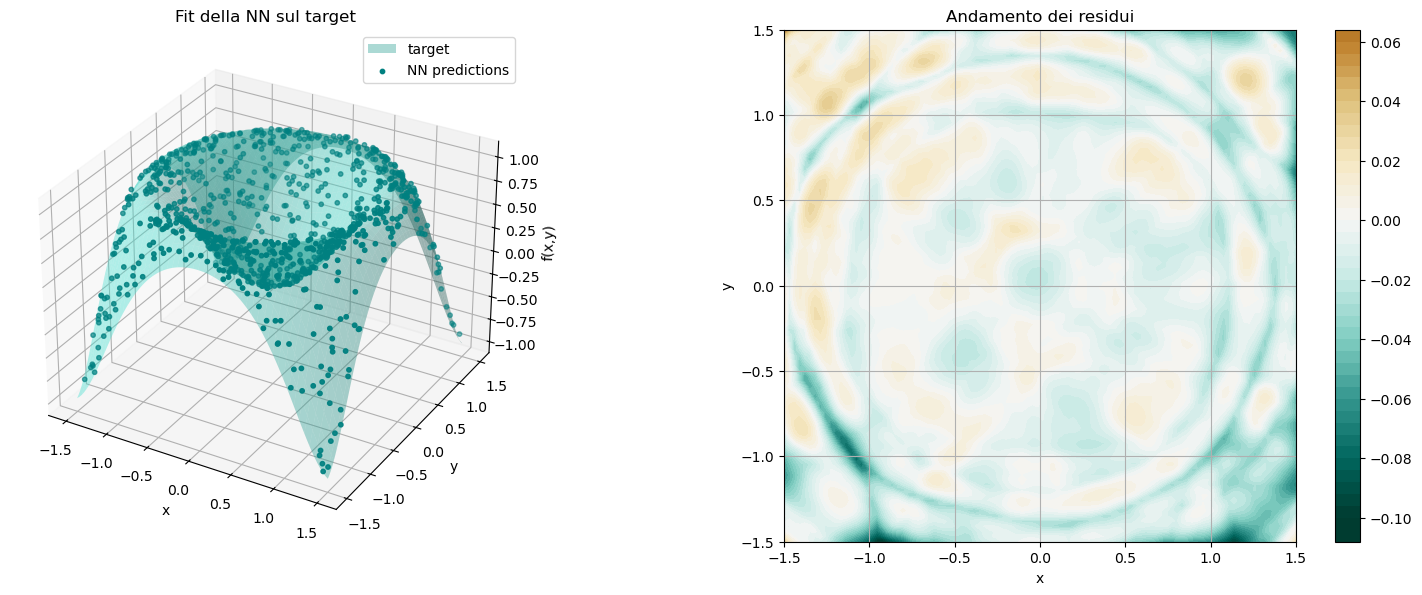

In [48]:
# genera 100 punti casuali nel dominio
x_test = np.random.uniform(-1.5, 1.5, 1000)
y_test = np.random.uniform(-1.5, 1.5, 1000)
XY_test = np.column_stack([x_test, y_test])
z_test_pred = model.predict(XY_test).flatten()

# residui sulla griglia
XY_grid = np.column_stack([x_grid.ravel(), y_grid.ravel()])
z_pred = model.predict(XY_grid).reshape(100, 100)
residuals_grid = z_grid - z_pred

fig = plt.figure(figsize=(16, 6))

# --- Grafico 1: fit 3D ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(x_grid, y_grid, z_grid, alpha=0.4, color='turquoise', label='target')
ax1.scatter(x_test, y_test, z_test_pred, color='teal', s=10, zorder=5, label='NN predictions')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('f(x,y)')
ax1.set_title('Fit della NN sul target')
ax1.legend()
ax1.grid(True)

# --- Grafico 2: mappa residui ---
ax2 = fig.add_subplot(122)
im = ax2.contourf(x_grid, y_grid, residuals_grid, levels=50, cmap='BrBG_r', vmin=-0.1, vmax=0.1)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Andamento dei residui')
plt.colorbar(im, ax=ax2)
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Il grafico 3D mostra un ottimo accordo tra i punti predetti e la superficie target su tutto il dominio. La mappa dei residui conferma il miglioramento rispetto alla configurazione iniziale a tre layer (64-32-16): i residui sono ora contenuti nell'intervallo $\approx \pm 0.06$ sulla maggior parte del dominio, con deviazioni più marcate solo sull'anello esterno dove le oscillazioni della funzione sono più rapide. La struttura radiale dei residui riflette il limite intrinseco di una rete feed-forward con ReLU nell'approssimare funzioni periodiche ad alta frequenza, ma il risultato complessivo è soddisfacente e costituisce la configurazione migliore ottenuta in questo esercizio.

### Conclusioni
La rete con quattro layer Dense (128-64-32-16), attivazione ReLU e ottimizzatore SGD ha prodotto il risultato migliore, con una MSE sul target di $\approx 2.6 \times 10^{-4}$. Rispetto agli esercizi precedenti, questo problema ha evidenziato che aumentare la dimensionalità dell'input richiede un'architettura più profonda e larga.  I residui strutturati sugli anelli esterni riflettono la difficoltà intrinseca di approssimare funzioni con oscillazioni rapide usando un numero finito di parametri: una rete più capiente o un campionamento più denso nelle regioni periferiche costituirebbero la direzione naturale per ridurli ulteriormente.